# Notebook 08 — Comparaison des expériences (paramètres généraux et spécifiques)

**Objectif de ce notebook :**
1. Charger le **journal des expériences** (`outputs/journal_experiences.parquet`),
   alimenté par les notebooks 04, 05 et 06 à chaque exécution (voir `journal.py`)
2. Construire **un tableau par modèle et par jeu d'hyperparamètres spécifiques testé** :
   chaque ligne du tableau correspond à un lancement avec des **paramètres généraux**
   différents (prédicteurs, mode de fenêtre, seuils de filtrage...), et inclut aussi les
   mesures de portefeuille long-short (Sharpe, Sortino...) du notebook 07 dès qu'elles ont
   été calculées au moins une fois pour cette ligne précise (voir section 2)
3. Visualiser ces différences avec quelques graphiques (classement de toutes les
   expériences, compromis précision/temps de calcul, effet des paramètres généraux)
4. Faire ressortir la meilleure expérience de chaque modèle, et la meilleure au global

⚠️ **Ce notebook ne ré-entraîne rien.** Il lit uniquement le journal déjà rempli par
04/05/06, et l'historique cumulatif `outputs/historique_performance_portefeuilles.parquet`
alimenté par 07 -- voir la section 1 si le journal est encore vide.

ℹ️ **Différence avec le notebook 07** : le notebook 07 lit `outputs/resultats_*.parquet`
et `outputs/predictions_*.parquet`, qui sont **écrasés** à chaque nouvelle exécution de
04/05/06 — il montre donc toujours le **dernier** modèle entraîné de chaque type, avec le
détail complet des portefeuilles long-short (graphiques par décile, richesse cumulée...).
Ce notebook 08 lit au contraire deux fichiers qui ne sont **jamais écrasés** (seulement
complétés, sans doublon) : `outputs/journal_experiences.parquet` (résultats agrégés de
CHAQUE lancement passé de 04/05/06) et `outputs/historique_performance_portefeuilles.parquet`
(mesures de portefeuille de CHAQUE expérience déjà évaluée par 07) — il sert donc à comparer
**plusieurs lancements passés entre eux**, portefeuilles inclus. Le **classement** de chaque
tableau reste basé sur le `R²_oos` (voir section 2), mais chaque ligne affiche aussi les
mesures de portefeuille dès qu'elles existent : `NaN` seulement pour les expériences que 07
n'a **encore jamais** évaluées (voir `journal.tableaux_par_modele` pour le détail).

**Comment produire de quoi comparer :** modifie un ou plusieurs paramètres dans
`config.py` (par exemple `TYPE_FENETRE`, `PREDICTEURS`, `SEUIL_PERCENTILE_TAILLE`, ou les
grilles d'hyperparamètres de l'Elastic Net / LightGBM), relance le(s) notebook(s)
concerné(s) (04, 05 et/ou 06 — inutile de relancer 03 sauf si tu as changé
`SEUIL_PERCENTILE_TAILLE` ou `SEUIL_PERCENTILE_LIQUIDITE`), puis reviens ici et
ré-exécute ce notebook : la nouvelle expérience apparaît automatiquement, sans rien
perdre des précédentes. Relancer deux fois exactement les mêmes paramètres ne crée
jamais de doublon (voir `journal.enregistrer_experience`). Pour que cette nouvelle
expérience ait aussi ses mesures de portefeuille, relance également le notebook 07
(automatique si tu passes par le notebook 00 -- voir README.md) : une fois calculées,
elles restent dans l'historique même après un lancement suivant.

## 0. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display
import sys
sys.path.append("..")  # pour pouvoir importer config.py et journal.py, situes a la racine du projet
import config
import journal

config.assurer_dossiers()

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

# Une couleur fixe par modele, reutilisee dans tous les graphiques de ce notebook pour
# rester coherent d'une section a l'autre.
COULEURS_MODELE = {
    'Regression lineaire': 'tab:blue',
    'Elastic Net': 'tab:orange',
    'LightGBM': 'tab:green',
}

def couleur_modele(nom_modele):
    return COULEURS_MODELE.get(nom_modele, 'tab:gray')


def label_experience(ligne, max_len=48):
    """Construit une etiquette courte 'Modele | parametres specifiques' pour une ligne du
    journal, utilisee comme etiquette d'axe dans les graphiques des sections 3 et 4 --
    tronquee a max_len caracteres pour rester lisible."""
    detail = ligne['params_specifiques_label']
    if detail == "(aucun hyperparametre)":
        return ligne['modele']
    if len(detail) > max_len:
        detail = detail[:max_len - 1] + "…"
    return f"{ligne['modele']} | {detail}"

## 1. Chargement du journal des expériences

Une ligne par (modèle, paramètres généraux, paramètres spécifiques) déjà lancé — voir
`journal.py` pour la logique complète (déduplication, construction de la clé
d'expérience...).

In [2]:
df_journal = journal.charger_journal()

if len(df_journal) == 0:
    print("Le journal est vide (outputs/journal_experiences.parquet n'existe pas encore, ou est vide).")
    print("Lance au moins une fois les notebooks 04, 05 et/ou 06 -- chacun y ajoute une ligne")
    print("automatiquement a sa derniere cellule -- puis reviens executer ce notebook.")
else:
    print(f"{len(df_journal)} experience(s) au total dans le journal.\n")
    print("Repartition par modele :")
    print(df_journal['modele'].value_counts().to_string())
    print()
    print("Repartition par (modele, jeu d'hyperparametres specifiques) :")
    print(df_journal.groupby(['modele', 'params_specifiques_label']).size().to_string())

9 experience(s) au total dans le journal.

Repartition par modele :
modele
Regression lineaire    4
Elastic Net            3
LightGBM               2

Repartition par (modele, jeu d'hyperparametres specifiques) :
modele               params_specifiques_label                                                                                                                                  
Elastic Net          grille_alpha=[1e-05..0.1] (5 val.), grille_l1_ratio=[0.1..0.9] (5 val.), max_iter=1000                                                                        1
                     grille_alpha=[1e-07..0.1] (10 val.), grille_l1_ratio=[0.1..0.9] (5 val.), max_iter=1000                                                                       2
LightGBM             grille_num_leaves=[7, 15, 31], grille_learning_rate=[0.005, 0.01, 0.03], grille_min_child_samples=[500, 2000, 5000], n_estimators=1000, stopping_rounds=50    2
Regression lineaire  (aucun hyperparametre)                         

## 2. Tableaux par modèle et par jeu d'hyperparamètres spécifiques

Un tableau par (modèle, paramètres **spécifiques**) — deux lancements du même modèle
avec les mêmes hyperparamètres spécifiques mais des paramètres **généraux** différents
(ex: `expanding` vs `rolling`) apparaissent comme **deux lignes du même tableau** ; deux
lancements avec des hyperparamètres spécifiques différents (ex: deux grilles d'`alpha`
pour l'Elastic Net) donnent **deux tableaux distincts**. Chaque tableau est **trié par
`r2_oos_test` décroissant** (le classement reste basé sur la précision statistique), et
inclut la durée totale d'entraînement (toutes fenêtres).

ℹ️ Chaque tableau inclut aussi les mesures de performance du portefeuille
long-short associé -- ratio de **Sharpe**, de **Sortino**, rendement et volatilité
annualisés, **drawdown** maximum, t-stat et % de mois positifs (voir notebook 07, partie
B) -- lues dans `outputs/historique_performance_portefeuilles.parquet`, un historique
**cumulatif** (jamais écrasé, alimenté par le notebook 07 à chaque exécution) : une
expérience garde ses mesures de portefeuille même après avoir été supplantée par un
lancement plus récent du même modèle. ⚠️ Ces colonnes valent `NaN` uniquement pour les
expériences que le notebook 07 n'a **encore jamais évaluées** (ex: tu viens de relancer
05 avec de nouveaux paramètres mais tu n'as pas encore relancé 07 depuis) -- ce n'est pas
une erreur, juste une question de timing : relance 07 pour les faire apparaître.

In [3]:
groupes = journal.tableaux_par_modele(df_journal)

# Mesures de portefeuille (voir notebook 07, partie B) affichees dans chaque tableau,
# en plus du R2_oos qui reste le critere de tri -- NaN uniquement quand le notebook 07 n'a
# ENCORE JAMAIS evalue cette experience (voir section 2 ci-dessus).
COLONNES_PORTEFEUILLE_AFFICHEES = [
    'sharpe_ratio', 'sortino_ratio', 'rendement_annualise', 'volatilite_annualisee',
    'max_drawdown', 't_stat', 'pct_mois_positifs',
]

if not groupes:
    print("Rien a afficher (journal vide) -- voir section 1.")
else:
    for g in groupes:
        tableau_affiche = g['tableau'].drop(columns=['cle_experience']).copy()
        for col in ['r2_oos_train', 'r2_oos_validation', 'r2_oos_test'] + COLONNES_PORTEFEUILLE_AFFICHEES:
            tableau_affiche[col] = tableau_affiche[col].round(4)
        tableau_affiche['duree_entrainement_(s)'] = tableau_affiche['duree_entrainement_(s)'].round(1)

        n_avec_portefeuille = g['tableau']['sharpe_ratio'].notna().sum()

        print("=" * 110)
        print(f"{g['modele']}  --  {g['params_specifiques_label']}")
        print("=" * 110)
        display(tableau_affiche)
        if n_avec_portefeuille == 0:
            print("(mesures de portefeuille indisponibles pour ce groupe pour l'instant -- "
                  "execute/relance le notebook 07 pendant que les predictions de l'une de "
                  "ces experiences sont sur disque pour les faire apparaitre ici.)")
        elif n_avec_portefeuille < len(tableau_affiche):
            print(f"({n_avec_portefeuille}/{len(tableau_affiche)} ligne(s) avec mesures de "
                  "portefeuille -- les autres n'ont pas encore ete evaluees par le "
                  "notebook 07, voir la section 2 ci-dessus.)")
        print()


Elastic Net  --  grille_alpha=[1e-07..0.1] (10 val.), grille_l1_ratio=[0.1..0.9] (5 val.), max_iter=1000


,date_experience,n_predicteurs,type_fenetre,annees_train_initial,annees_validation,annees_test_par_fenetre,seuil_percentile_taille,seuil_percentile_liquidite,duree_entrainement_(s),r2_oos_train,r2_oos_validation,r2_oos_test,n_fenetres,sharpe_ratio,sortino_ratio,rendement_annualise,volatilite_annualisee,max_drawdown,t_stat,p_value,pct_mois_positifs,skewness,kurtosis,n_mois
0,2026-07-22T15:41:23,25,expanding,18,12,4,0.1,0.9,801.8,0.0026,0.0020,0.0042,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-07-22T14:32:12,25,expanding,18,12,15,0.1,0.9,192.0,0.0036,0.0011,0.0041,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(mesures de portefeuille indisponibles pour ce groupe pour l'instant -- execute/relance le notebook 07 pendant que les predictions de l'une de ces experiences sont sur disque pour les faire apparaitre ici.)

Elastic Net  --  grille_alpha=[1e-05..0.1] (5 val.), grille_l1_ratio=[0.1..0.9] (5 val.), max_iter=1000


,date_experience,n_predicteurs,type_fenetre,annees_train_initial,annees_validation,annees_test_par_fenetre,seuil_percentile_taille,seuil_percentile_liquidite,duree_entrainement_(s),r2_oos_train,r2_oos_validation,r2_oos_test,n_fenetres,sharpe_ratio,sortino_ratio,rendement_annualise,volatilite_annualisee,max_drawdown,t_stat,p_value,pct_mois_positifs,skewness,kurtosis,n_mois
0,2026-07-27T19:31:18,60,expanding,18,12,4,0.1,0.9,568.3,0.0001,-0.0001,0.0003,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(mesures de portefeuille indisponibles pour ce groupe pour l'instant -- execute/relance le notebook 07 pendant que les predictions de l'une de ces experiences sont sur disque pour les faire apparaitre ici.)

LightGBM  --  grille_num_leaves=[7, 15, 31], grille_learning_rate=[0.005, 0.01, 0.03], grille_min_child_samples=[500, 2000, 5000], n_estimators=1000, stopping_rounds=50


,date_experience,n_predicteurs,type_fenetre,annees_train_initial,annees_validation,annees_test_par_fenetre,seuil_percentile_taille,seuil_percentile_liquidite,duree_entrainement_(s),r2_oos_train,r2_oos_validation,r2_oos_test,n_fenetres,sharpe_ratio,sortino_ratio,rendement_annualise,volatilite_annualisee,max_drawdown,t_stat,p_value,pct_mois_positifs,skewness,kurtosis,n_mois
0,2026-07-22T16:09:18,25,expanding,18,12,4,0.1,0.9,1665.0,0.0113,0.0036,0.0041,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-07-22T14:51:33,25,expanding,18,12,15,0.1,0.9,1154.1,0.0274,0.0037,-0.0004,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(mesures de portefeuille indisponibles pour ce groupe pour l'instant -- execute/relance le notebook 07 pendant que les predictions de l'une de ces experiences sont sur disque pour les faire apparaitre ici.)

Regression lineaire  --  (aucun hyperparametre)


,date_experience,n_predicteurs,type_fenetre,annees_train_initial,annees_validation,annees_test_par_fenetre,seuil_percentile_taille,seuil_percentile_liquidite,duree_entrainement_(s),r2_oos_train,r2_oos_validation,r2_oos_test,n_fenetres,sharpe_ratio,sortino_ratio,rendement_annualise,volatilite_annualisee,max_drawdown,t_stat,p_value,pct_mois_positifs,skewness,kurtosis,n_mois
0,2026-07-23T21:49:51,1,expanding,18,12,4,0.1,0.9,78.8,0.0025,0.0014,0.0036,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-07-22T15:27:48,25,expanding,18,12,4,0.1,0.9,10.9,0.0042,0.0013,0.0029,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-07-22T14:28:54,25,expanding,18,12,15,0.1,0.9,2.8,0.0054,0.0007,0.0024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-07-24T20:00:50,60,expanding,18,12,4,0.1,0.9,53.9,0.0057,0.0017,0.0022,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(mesures de portefeuille indisponibles pour ce groupe pour l'instant -- execute/relance le notebook 07 pendant que les predictions de l'une de ces experiences sont sur disque pour les faire apparaitre ici.)



## 3. Classement de toutes les expériences (R²_oos test)

Toutes les expériences loggées, triées par `r2_oos_test` décroissant, une barre
horizontale par expérience -- l'étiquette de chaque barre indique le modèle **et** ses
hyperparamètres spécifiques (tronqués si trop longs ; voir les tableaux de la section 2
pour le détail complet). Couleur = modèle, comme partout ailleurs dans ce notebook.

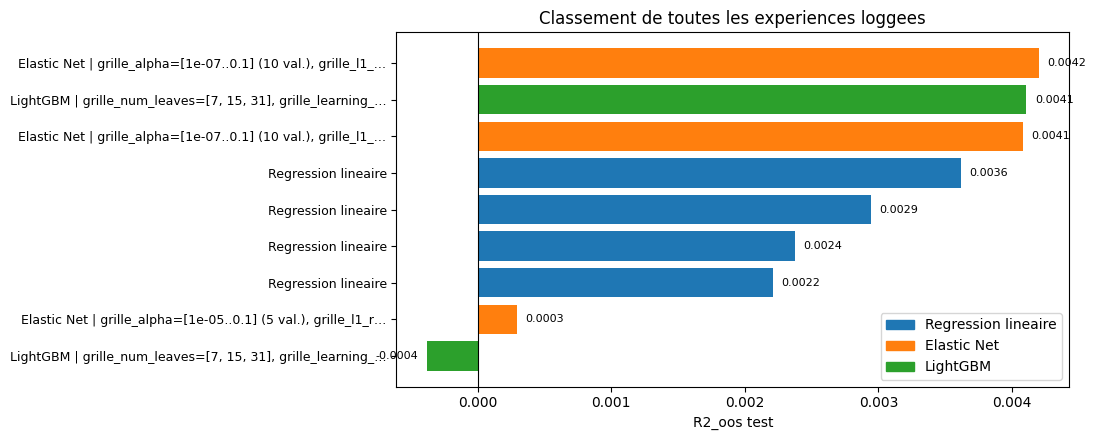

In [4]:
if len(df_journal) == 0:
    print("Rien a afficher (journal vide) -- voir section 1.")
else:
    df_tri = df_journal.sort_values('res_r2_oos_test', ascending=True).reset_index(drop=True)  # ascending : le plus grand en HAUT du barh
    etiquettes = [label_experience(row) for _, row in df_tri.iterrows()]
    couleurs = [couleur_modele(m) for m in df_tri['modele']]

    fig, ax = plt.subplots(figsize=(11, max(4.5, 0.5 * len(df_tri))))
    barres = ax.barh(range(len(df_tri)), df_tri['res_r2_oos_test'], color=couleurs)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(range(len(df_tri)))
    ax.set_yticklabels(etiquettes, fontsize=9)
    ax.set_xlabel("R2_oos test")
    ax.set_title("Classement de toutes les experiences loggees")

    # valeur exacte au bout de chaque barre
    for i, valeur in enumerate(df_tri['res_r2_oos_test']):
        decalage = df_tri['res_r2_oos_test'].abs().max() * 0.015
        ax.text(valeur + (decalage if valeur >= 0 else -decalage), i, f"{valeur:.4f}",
                va='center', ha='left' if valeur >= 0 else 'right', fontsize=8)

    legende = [Patch(color=c, label=m) for m, c in COULEURS_MODELE.items() if m in df_tri['modele'].values]
    ax.legend(handles=legende, loc='lower right')
    plt.tight_layout()
    plt.show()

## 4. Compromis précision / temps de calcul

Un modèle plus lent à entraîner (recherche d'hyperparamètres plus large, grille plus
fine...) apporte-t-il vraiment un meilleur `R²_oos test` ? Utile en particulier pour
LightGBM, de loin le plus coûteux en calcul des trois (voir notebook 06). La **taille**
de chaque point est proportionnelle à son **nombre de fenêtres entraînées**
(`n_fenetres`), et chaque point est annoté avec ses **hyperparamètres spécifiques**
(tronqués si trop longs).

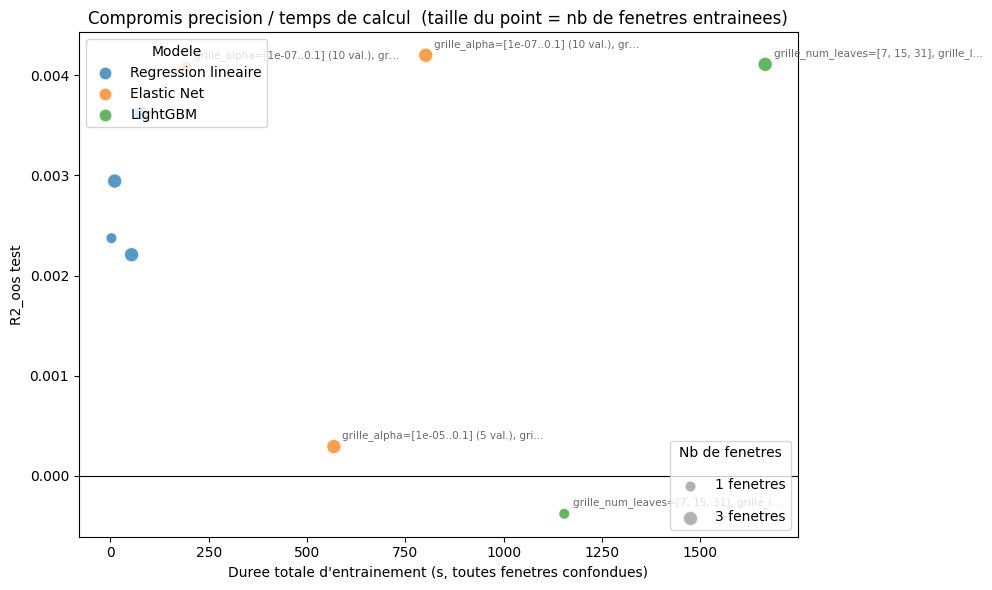

In [5]:
if len(df_journal) == 0:
    print("Rien a afficher (journal vide) -- voir section 1.")
else:
    # Taille des points proportionnelle a n_fenetres (avec un plancher pour rester visible
    # meme avec peu de fenetres) -- voir la legende de tailles ajoutee sous le graphique.
    def taille_marqueur(n_fenetres):
        return 40 + 22 * n_fenetres

    fig, ax = plt.subplots(figsize=(10, 6))
    for m in df_journal['modele'].unique():
        sous = df_journal[df_journal['modele'] == m]
        ax.scatter(sous['duree_entrainement_secondes'], sous['res_r2_oos_test'],
                   s=taille_marqueur(sous['res_n_fenetres']),
                   label=m, color=couleur_modele(m), alpha=0.75, edgecolor='white', linewidth=0.8)
        # annotation : hyperparametres specifiques de chaque experience
        for _, ligne in sous.iterrows():
            detail = ligne['params_specifiques_label']
            if detail == "(aucun hyperparametre)":
                continue
            if len(detail) > 40:
                detail = detail[:39] + "…"
            ax.annotate(detail, xy=(ligne['duree_entrainement_secondes'], ligne['res_r2_oos_test']),
                        xytext=(6, 6), textcoords='offset points', fontsize=7.5, color='dimgray')

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel("Duree totale d'entrainement (s, toutes fenetres confondues)")
    ax.set_ylabel("R2_oos test")
    ax.set_title("Compromis precision / temps de calcul  (taille du point = nb de fenetres entrainees)")

    legende_modeles = ax.legend(loc='upper left', title="Modele")
    ax.add_artist(legende_modeles)

    # legende manuelle pour la taille des points (n_fenetres)
    valeurs_repere = sorted(set(df_journal['res_n_fenetres'])) or [1]
    valeurs_repere = [valeurs_repere[0], valeurs_repere[len(valeurs_repere) // 2], valeurs_repere[-1]]
    valeurs_repere = sorted(set(valeurs_repere))
    poignees_taille = [plt.scatter([], [], s=taille_marqueur(v), color='gray', alpha=0.6, edgecolor='white')
                        for v in valeurs_repere]
    ax.legend(poignees_taille, [f"{v} fenetres" for v in valeurs_repere],
              loc='lower right', title="Nb de fenetres", labelspacing=1.3)

    plt.tight_layout()
    plt.show()

## 5. Effet des paramètres généraux sur le R²_oos test

Pour chaque paramètre général ayant été testé avec **au moins deux valeurs différentes**
dans le journal (sinon rien à comparer, ce panneau est simplement omis), un nuage de
points `R²_oos test` par valeur de ce paramètre, toutes expériences confondues et
colorées par modèle. Vue d'ensemble exploratoire — pour une comparaison **contrôlée**
(mêmes hyperparamètres spécifiques, seul un paramètre général change), voir plutôt les
tableaux de la section 2.

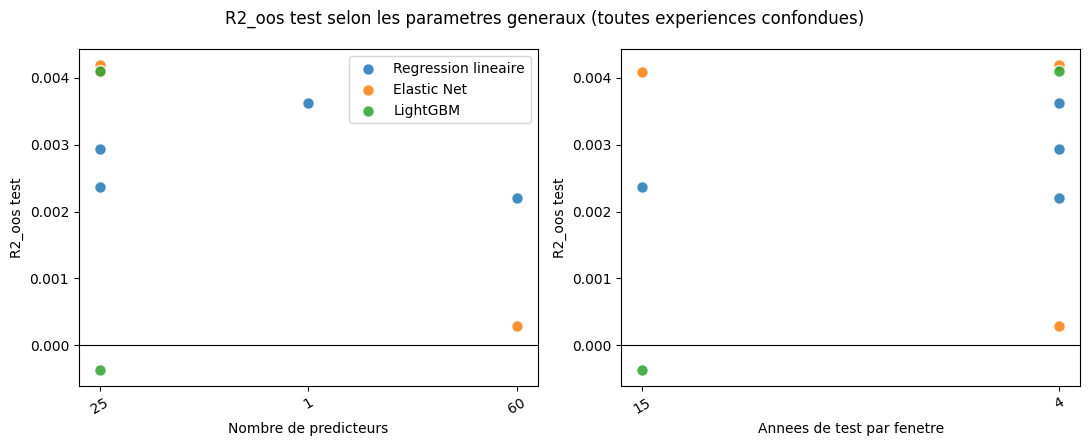

In [6]:
PARAMS_GENERAUX_A_EXPLORER = {
    'gen_type_fenetre': "Mode de fenetre",
    'gen_n_predicteurs': "Nombre de predicteurs",
    'gen_annees_train_initial': "Annees de train initial",
    'gen_annees_validation': "Annees de validation",
    'gen_annees_test_par_fenetre': "Annees de test par fenetre",
    'gen_seuil_percentile_taille': "Seuil percentile taille (mvel1)",
    'gen_seuil_percentile_liquidite': "Seuil percentile liquidite (ill)",
}

if len(df_journal) == 0:
    print("Rien a afficher (journal vide) -- voir section 1.")
else:
    params_variables = [c for c in PARAMS_GENERAUX_A_EXPLORER if df_journal[c].nunique() > 1]

    if not params_variables:
        print("Un seul jeu de parametres generaux a ete teste jusqu'ici -- rien a comparer.")
        print("Change par exemple TYPE_FENETRE ou PREDICTEURS dans config.py, relance 04/05/06,")
        print("puis reviens executer ce notebook pour enrichir cette section.")
    else:
        fig, axes = plt.subplots(1, len(params_variables), figsize=(5.5 * len(params_variables), 4.5), squeeze=False)
        axes = axes[0]
        for ax, col in zip(axes, params_variables):
            for m in df_journal['modele'].unique():
                sous = df_journal[df_journal['modele'] == m]
                ax.scatter(sous[col].astype(str), sous['res_r2_oos_test'],
                           label=m, color=couleur_modele(m), s=70, alpha=0.85, edgecolor='white')
            ax.axhline(0, color='black', linewidth=0.8)
            ax.set_xlabel(PARAMS_GENERAUX_A_EXPLORER[col])
            ax.set_ylabel("R2_oos test")
            ax.tick_params(axis='x', rotation=30)
        axes[0].legend()
        fig.suptitle("R2_oos test selon les parametres generaux (toutes experiences confondues)")
        plt.tight_layout()
        plt.show()

## 6. Meilleure expérience par modèle, et au global

In [7]:
if len(df_journal) == 0:
    print("Rien a afficher (journal vide) -- voir section 1.")
else:
    print("Meilleure experience de chaque modele (au sens du R2_oos test) :\n")
    for m in df_journal['modele'].unique():
        sous = df_journal[df_journal['modele'] == m]
        meilleure = sous.loc[sous['res_r2_oos_test'].idxmax()]
        print(f"--- {m}  (R2_oos test = {meilleure['res_r2_oos_test']:.4f}) ---")
        print(f"  Parametres specifiques : {meilleure['params_specifiques_label']}")
        print(f"  Parametres generaux    : type_fenetre={meilleure['gen_type_fenetre']}, "
              f"n_predicteurs={meilleure['gen_n_predicteurs']}, "
              f"annees_test_par_fenetre={meilleure['gen_annees_test_par_fenetre']}, "
              f"seuil_taille={meilleure['gen_seuil_percentile_taille']}, "
              f"seuil_liquidite={meilleure['gen_seuil_percentile_liquidite']}")
        print(f"  R2_oos train/validation : {meilleure['res_r2_oos_train']:.4f} / {meilleure['res_r2_oos_validation']:.4f}")
        print(f"  Duree d'entrainement    : {meilleure['duree_entrainement_secondes']:.1f} s "
              f"({meilleure['res_n_fenetres']} fenetres)")
        print()

    meilleure_globale = df_journal.loc[df_journal['res_r2_oos_test'].idxmax()]
    print("=" * 90)
    print(f"MEILLEURE EXPERIENCE TOUS MODELES CONFONDUS : {meilleure_globale['modele']} "
          f"(R2_oos test = {meilleure_globale['res_r2_oos_test']:.4f})")
    print("=" * 90)

Meilleure experience de chaque modele (au sens du R2_oos test) :

--- Regression lineaire  (R2_oos test = 0.0036) ---
  Parametres specifiques : (aucun hyperparametre)
  Parametres generaux    : type_fenetre=expanding, n_predicteurs=1, annees_test_par_fenetre=4, seuil_taille=0.1, seuil_liquidite=0.9
  R2_oos train/validation : 0.0025 / 0.0014
  Duree d'entrainement    : 78.8 s (3 fenetres)

--- Elastic Net  (R2_oos test = 0.0042) ---
  Parametres specifiques : grille_alpha=[1e-07..0.1] (10 val.), grille_l1_ratio=[0.1..0.9] (5 val.), max_iter=1000
  Parametres generaux    : type_fenetre=expanding, n_predicteurs=25, annees_test_par_fenetre=4, seuil_taille=0.1, seuil_liquidite=0.9
  R2_oos train/validation : 0.0026 / 0.0020
  Duree d'entrainement    : 801.8 s (3 fenetres)

--- LightGBM  (R2_oos test = 0.0041) ---
  Parametres specifiques : grille_num_leaves=[7, 15, 31], grille_learning_rate=[0.005, 0.01, 0.03], grille_min_child_samples=[500, 2000, 5000], n_estimators=1000, stopping_rounds

## 7. Résumé

- Ce notebook compare des **expériences deja lancees** (04/05/06) entre elles, sur la base
  du `R²_oos` (train/validation/test) et du temps d'entraînement -- il ne ré-entraîne rien
  et ne touche pas aux fichiers écrits par le notebook 07.
- Un tableau par (modèle, hyperparamètres **spécifiques**), une ligne par jeu de
  paramètres **généraux** testé avec ces hyperparamètres (section 2) -- **trié par
  `R²_oos test`**, et enrichi des mesures de portefeuille long-short du
  notebook 07 (Sharpe, Sortino, drawdown...) pour **chaque** expérience déjà évaluée par 07
  au moins une fois (`NaN` seulement pour celles jamais évaluées, voir section 2 et
  README.md) -- ces mesures, une fois calculées, restent disponibles même après un
  lancement suivant du même modèle.
- Pour ajouter une expérience : change un paramètre dans `config.py`, relance le(s)
  notebook(s) concerné(s) (04/05/06, et 03 si tu as touché aux seuils de filtrage),
  ré-exécute ce notebook -- aucun doublon si les paramètres n'ont pas changé. Relance
  aussi le notebook 07 pour que cette nouvelle expérience obtienne ses mesures de
  portefeuille (automatique si tu passes par le notebook 00).
- Pour repartir de zéro : supprime `outputs/journal_experiences.parquet` et/ou
  `outputs/historique_performance_portefeuilles.parquet` (les autres fichiers de
  `outputs/` et `modeles/` ne sont pas affectés).
- Le notebook 07 reste la référence pour le détail complet de l'évaluation économique
  (graphiques par décile, richesse cumulée...) du **dernier** modèle entraîné de chaque
  type -- ce notebook n'en reprend qu'un résumé chiffré, par expérience.
